# Klasifikasi Sawah dan Bukan Sawah dengan Random Forest

Notebook ini mengikuti alur utama [`01. Machine_Learning.ipynb`](https://github.com/yotarazona/scikit-eo/blob/main/examples/notebooks/01.%20Machine_Learning.ipynb) dari scikit-eo: membaca citra, menyiapkan sampel berlabel, melatih Random Forest, mengevaluasi hasil, membuat peta klasifikasi, dan menyimpan raster hasil. Data citra Sentinel-2 (band B01–B04) dan poligon GeoJSON yang digunakan mengambil lokasi di Lenteng, Kabupaten Sumenep.

## 1. Instalasi dan import library
Jalankan instalasi bila library belum tersedia. Disarankan memakai Google Colab atau environment Python dengan GDAL/rasterio yang sudah terpasang.

In [1]:
!pip install rasterio geopandas shapely scikit-learn matplotlib pandas

In [2]:
import os, zipfile, json
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import geometry_mask
from shapely.geometry import shape, mapping
from shapely import make_valid
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, cohen_kappa_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## 2. Membaca data
Unggah `lenteng.zip` dan `data mentah.geojson` ke folder kerja notebook, atau ubah variabel path sesuai lokasi file.

In [9]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_path = "lenteng.zip"

data_dir = "lenteng_data"
os.makedirs(data_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(data_dir)

files = os.listdir(data_dir)

print("File berhasil diekstrak:")
for file in files:
    print(file)

Saving lenteng.zip to lenteng.zip
File berhasil diekstrak:
2026-10-01-00_00_2026-10-01-23_59_Sentinel-2_L2A_B01_(Raw).tiff
2026-10-01-00_00_2026-10-01-23_59_Sentinel-2_L2A_B02_(Raw).tiff
2026-10-01-00_00_2026-10-01-23_59_Sentinel-2_L2A_True_color.tiff
2026-10-01-00_00_2026-10-01-23_59_Sentinel-2_L2A_B03_(Raw).tiff
2026-10-01-00_00_2026-10-01-23_59_Sentinel-2_L2A_B04_(Raw).tiff


In [10]:
band_files = {}
for band in ["B01", "B02", "B03", "B04"]:
    matches = [os.path.join(data_dir, f) for f in files if band in f and f.lower().endswith((".tif", ".tiff"))]
    if not matches: raise FileNotFoundError(f"Raster untuk {band} tidak ditemukan")
    band_files[band] = matches[0]

with rasterio.open(band_files["B01"]) as src:
    profile = src.profile.copy()
    transform = src.transform
    crs = src.crs
    height, width = src.height, src.width
    bounds = src.bounds

arrays = []
for band in ["B01", "B02", "B03", "B04"]:
    with rasterio.open(band_files[band]) as src:
        if (src.width, src.height, src.transform, src.crs) != (width, height, transform, crs):
            raise ValueError(f"Raster {band} tidak sejajar dengan B01")
        arrays.append(src.read(1).astype("float32"))
image = np.stack(arrays, axis=-1)
print("Ukuran citra (baris, kolom, band):", image.shape)
print("CRS:", crs, "Bounds:", bounds)

Ukuran citra (baris, kolom, band): (424, 565, 4)
CRS: EPSG:4326 Bounds: BoundingBox(left=113.746777, bottom=-7.080962, right=113.8484, top=-7.005149)


In [22]:
import json
import pandas as pd
from google.colab import files
from shapely.geometry import shape
from shapely.validation import make_valid

uploaded = files.upload()

geojson_path = next(iter(uploaded))

print("File GeoJSON yang digunakan:", geojson_path)

with open(geojson_path, "r", encoding="utf-8") as f:
    geojson = json.load(f)

features = []

for feat in geojson.get("features", []):
    geom_data = feat.get("geometry")
    props = feat.get("properties", {}) or {}

    label = props.get("type")
    if not geom_data or label not in ["sawah", "bukan sawah"]:
        continue

    try:
        geom = shape(geom_data)
        if not geom.is_valid:
            geom = make_valid(geom)

        if geom.is_empty or not geom.is_valid:
            continue

        if geom.geom_type in ["Polygon", "MultiPolygon"]:
            features.append({
                "geometry": geom,
                "label": label
            })

    except Exception as e:
        print("Geometri dilewati:", e)

print("Jumlah poligon yang dapat digunakan:", len(features))
print("\nJumlah masing-masing kelas:")
print(
    pd.Series(
        [x["label"] for x in features]
    ).value_counts()
)

Saving sawah.geojson to sawah.geojson
File GeoJSON yang digunakan: sawah.geojson
Jumlah poligon yang dapat digunakan: 100

Jumlah masing-masing kelas:
sawah          50
bukan sawah    50
Name: count, dtype: int64


## 3. Ekstraksi nilai spektral untuk training
Setiap poligon digunakan untuk mengambil piksel di dalam area sampel. Semua piksel di dalam poligon mewarisi label `type` poligon tersebut.

In [23]:
X_list, y_list = [], []
for item in features:
    geom = item["geometry"]
    try:
        inside = geometry_mask([mapping(geom)], out_shape=(height, width), transform=transform, invert=True, all_touched=False)
        valid = inside & np.all(np.isfinite(image), axis=-1)
        pixels = image[valid]
        if pixels.size:
            X_list.append(pixels)
            y_list.extend([item["label"]] * len(pixels))
    except Exception as e:
        print("Poligon dilewati saat ekstraksi:", e)

if not X_list:
    raise ValueError("Tidak ada piksel sampel yang berhasil diekstrak. Periksa CRS dan lokasi GeoJSON terhadap raster.")
X = np.vstack(X_list)
y = np.asarray(y_list)
print("Jumlah sampel piksel:", len(y))
print(pd.Series(y).value_counts())
print("Fitur yang digunakan: B01, B02, B03, B04")

Jumlah sampel piksel: 218
sawah          171
bukan sawah     47
Name: count, dtype: int64
Fitur yang digunakan: B01, B02, B03, B04


## 4. Membagi data dan melatih Random Forest
Pembagian data menggunakan 80% training dan 20% testing, mengikuti parameter pada contoh GitHub. Karena piksel dari poligon yang sama dapat saling mirip, hasil evaluasi ini perlu dibaca sebagai evaluasi berbasis piksel, bukan validasi spasial independen.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Training:", len(y_train), "Testing:", len(y_test))

Training: 174 Testing: 44


## 5. Evaluasi hasil
Notebook referensi menampilkan overall accuracy, kappa index, dan confusion matrix. Di sini juga ditampilkan precision, recall, dan F1-score.

Overall accuracy: 0.8864
Kappa index: 0.6646

Classification report:
              precision    recall  f1-score   support

 bukan sawah       0.70      0.78      0.74         9
       sawah       0.94      0.91      0.93        35

    accuracy                           0.89        44
   macro avg       0.82      0.85      0.83        44
weighted avg       0.89      0.89      0.89        44



,bukan sawah,sawah
bukan sawah,7,2
sawah,3,32


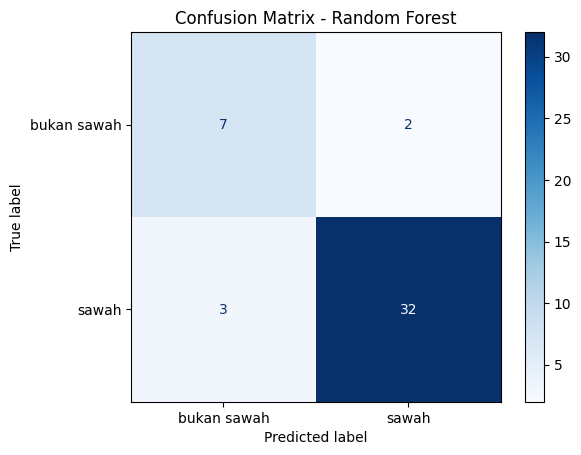

In [25]:
accuracy = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
labels = ["bukan sawah", "sawah"]
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("Overall accuracy:", round(accuracy, 4))
print("Kappa index:", round(kappa, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, labels=labels, zero_division=0))

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
display(cm_df)
cm_df.to_csv("confusion_matrix.csv", sep=";", index=True)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()

## 8. Membuat peta klasifikasi seluruh citra
Prediksi dilakukan untuk semua piksel yang memiliki nilai valid. Kode kelas disimpan sebagai 1 = bukan sawah dan 2 = sawah.

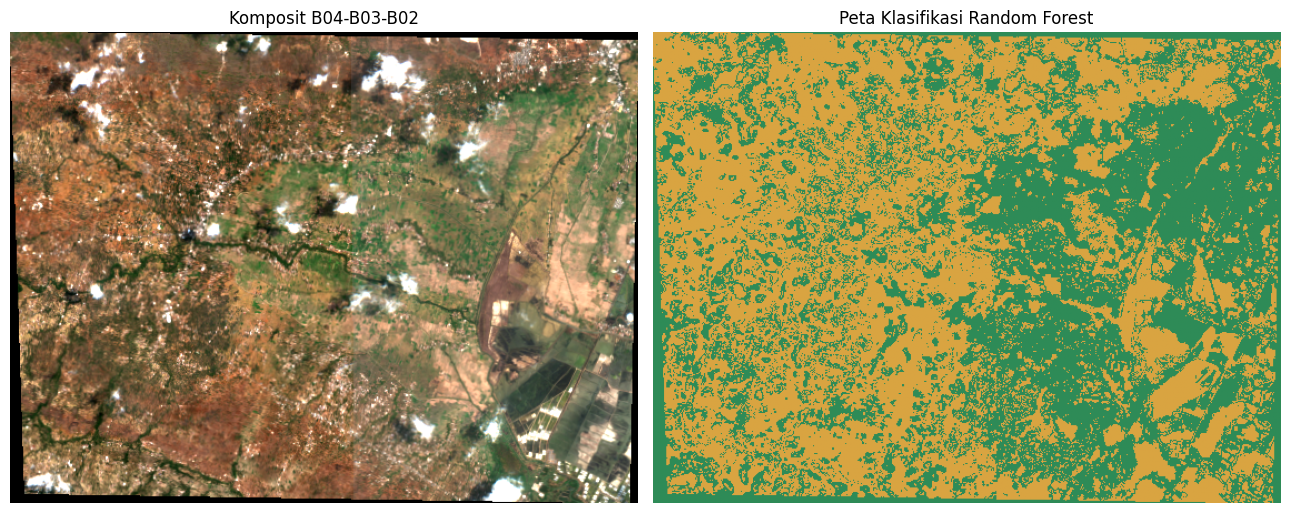


kuning = bukan sawah
hijau = sawah


In [30]:
class_map = np.zeros((height, width), dtype=np.uint8)
valid_pixels = np.all(np.isfinite(image), axis=-1)
if valid_pixels.any():
    predicted_all = rf.predict(image[valid_pixels])
    class_map[valid_pixels] = np.where(predicted_all == "sawah", 2, 1).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
# Tampilkan komposit warna semu dari B04, B03, B02
rgb = np.stack([image[:, :, 3], image[:, :, 2], image[:, :, 1]], axis=-1)
lo, hi = np.nanpercentile(rgb, [2, 98])
rgb_show = np.clip((rgb - lo) / (hi - lo + 1e-9), 0, 1)
axes[0].imshow(rgb_show)
axes[0].set_title("Komposit B04-B03-B02")
axes[0].axis("off")
axes[1].imshow(np.ma.masked_equal(class_map, 0), cmap=plt.matplotlib.colors.ListedColormap(["#d9a441", "#2e8b57"]), vmin=1, vmax=2)
axes[1].set_title("Peta Klasifikasi Random Forest")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print()
print("kuning = bukan sawah")
print("hijau = sawah")

## 7. Menyimpan peta klasifikasi ke GeoTIFF
Nilai 0 berarti piksel tidak valid/tidak diprediksi, 1 berarti bukan sawah, dan 2 berarti sawah.

In [28]:
out_profile = profile.copy()

# Hapus ukuran block dari profile lama
out_profile.pop("blockxsize", None)
out_profile.pop("blockysize", None)

out_profile.update(
    driver="GTiff",
    count=1,
    dtype="uint8",
    nodata=0,
    compress="lzw",
    tiled=True,
    blockxsize=256,
    blockysize=256
)

out_path = "klasifikasi_sawah_lenteng.tif"

with rasterio.open(out_path, "w", **out_profile) as dst:
    dst.write(class_map, 1)

print("Raster hasil disimpan:", out_path)

Raster hasil disimpan: klasifikasi_sawah_lenteng.tif


## 8. Catatan interpretasi
- Hasil klasifikasi bergantung pada kualitas dan ketepatan poligon label di GeoJSON.
- Jika label pada GeoJSON memiliki ejaan berbeda, sesuaikan daftar kelas pada bagian preprocessing.
- Untuk evaluasi yang lebih kuat, gunakan pemisahan training/testing berdasarkan poligon, bukan pembagian acak piksel, agar piksel dari poligon yang sama tidak tersebar ke kedua kelompok.